In [190]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt 
%matplotlib inline

In [191]:
# read in all the words
words = open('names.txt', 'r').read().splitlines()
words[:8]

['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']

In [192]:
len(words)

32033

In [193]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s, i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [194]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:

  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append

X = torch.tensor(X)
Y = torch.tensor(Y)

In [202]:
X.shape, Y.shape # dataset

(torch.Size([228146, 3]), torch.Size([228146]))

In [556]:
# build the dataset

def build_dataset(words):
  block_size = 4 # context length: how many characters do we take to predict the next one?
  X, Y = [], []
  for w in words:
  
    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append
  
  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])


torch.Size([182504, 4]) torch.Size([182504])
torch.Size([22737, 4]) torch.Size([22737])
torch.Size([22905, 4]) torch.Size([22905])


In [548]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10), generator=g) # change the embeddings features from 2 to 10
W1 = torch.randn((40, 200), generator=g) #* (5/3) / (40**0.5) # increase the hidden layer neurons from 100 to 300, then when changing the embeddings we decrease the hidden layer from 300 to 200 neurons
b1 = torch.randn(200, generator=g) #* 0.01
W2 = torch.randn((200, 27), generator=g) * 0.01   
b2 = torch.randn(27, generator=g) * 0.00
parameters = [C, W1, b1, W2, b2]

In [553]:
for i in range(10):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,)) # creates integers that index to our dataset
  # because we are doing minibatches the quality of our gradient is lower, it is not as reliable, it is not the actual gradient direction
  # but the gradient direction is good enough, even when it's estimating on only 32 examples that it is useful
  # it is much better to have an approximate gradient and just make more steps
  # than it is to evaluate the exact gradient and take fewer steps
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 40) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix]) 
  #print(loss.item())
  # diagnostics
  print(i, loss.item(), (h.abs() > 0.99).float().mean().item())
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())


#print(loss.item())


    
# the loss is small, because we only have 32 examples of the first 5 words and the parameters are 3.5k so it is very easy to fit those examples
# we are not achieving zero, because we have names starting with e,a etc , so ... will have different targets based on the starting letter of the name
# so it can never be 1

0 3.3250937461853027 0.6689062714576721
1 3.272826910018921 0.6595312356948853
2 3.0434763431549072 0.6707812547683716
3 3.164808988571167 0.6723437309265137
4 2.935699224472046 0.671875
5 3.0119996070861816 0.6695312261581421
6 2.878911018371582 0.6746875047683716
7 2.9143261909484863 0.6607812643051147
8 2.8314530849456787 0.6604687571525574
9 3.136314868927002 0.6546875238418579


In [557]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((27,10), generator=g) # change the embeddings features from 2 to 10
W1 = torch.randn((40, 200), generator=g) * (5/3) / (40**0.5) # increase the hidden layer neurons from 100 to 300, then when changing the embeddings we decrease the hidden layer from 300 to 200 neurons
b1 = torch.randn(200, generator=g) * 0.01
W2 = torch.randn((200, 27), generator=g) * 0.01   
b2 = torch.randn(27, generator=g) * 0.00
parameters = [C, W1, b1, W2, b2]

In [558]:
sum(p.nelement() for p in parameters) # number of parameters in total

13897

In [559]:
for p in parameters:
  p.requires_grad = True

In [560]:
# how do you determine the learning rate?
# first we take a very low step ie 0.0001, and we see that the loss is barely decreasing, that is too low of a step
# then we take a bigger step than the first (10x bigger) and we see that we are decreasing but slowly ---> good LOW RANGE
# after that we reset again the network and try to find a step where the loss explodes
# h=-1, reduces the loss but it is unstabled (wiggles)
# we try h=-10 and we see that the network isn't optimizing, the loss is INCREASING
# so we think that -1 will be good for UPPER RANGE

torch.linspace(0.001, 1, 1000) # creates 1000 numbers between 0.001 and 1
# but we don't want linear steps because from 0.001 to 0.01 that is a 10x increase we have 0.001,0.002,...,0.009,0.01 ---> 9 steps for a (0.01/0.001) = 10x increase!
# going from 0.990 to 1.000 we have 0.990,0.991,0.992,...,0.999,1.000 ---> 9 steps again for a 1/0.99 = 1.01x factor!
# that's why we are equal stepping on the exponent, not on the step
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre
#lrs

In [561]:
lri = []
lossi = []
stepi = []

In [562]:
for i in range(300000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,)) # creates integers that index to our dataset
  # because we are doing minibatches the quality of our gradient is lower, it is not as reliable, it is not the actual gradient direction
  # but the gradient direction is good enough, even when it's estimating on only 32 examples that it is useful
  # it is much better to have an approximate gradient and just make more steps
  # than it is to evaluate the exact gradient and take fewer steps
  
  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 2)
  h = torch.tanh(emb.view(-1, 40) @ W1 + b1) # (32, 100)
  logits = h @ W2 + b2 # (32, 27)
  # counts = logits.exp()
  # prob = counts / counts.sum(1, keepdims=True)
  # loss = -prob[torch.arange(32), Y].log().mean()
  loss = F.cross_entropy(logits, Ytr[ix]) 
  # pytorch does not create new intermediate tensors, like above (runs in a fused kernel). 
  #the backward pass becomes much more efficient, like tanh in micrograd, where at the backward we had (1-t**2), so we didn't recalculate each derivative of exp
  # also it is much more numerically well behaved
  #print(loss.item())
  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()
  # update
  #lr = lrs[i]
  lr = 0.1 if i < 100000 else 0.01
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  #lri.append(lre[i])
  stepi.append(i)
  lossi.append(loss.log10().item())


#print(loss.item())


    
# the loss is small, because we only have 32 examples of the first 5 words and the parameters are 3.5k so it is very easy to fit those examples
# we are not achieving zero, because we have names starting with e,a etc , so ... will have different targets based on the starting letter of the name
# so it can never be 1

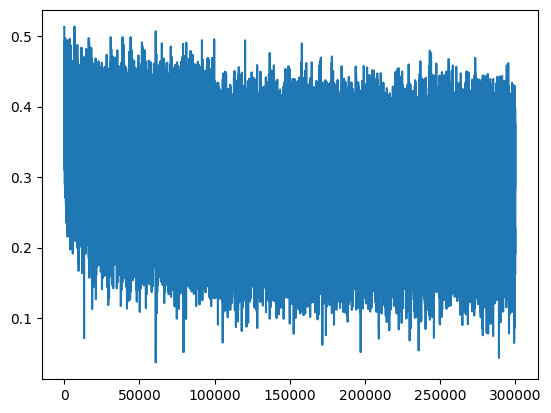

In [563]:
plt.plot(stepi, lossi) # the wiggling on the cart could be from the batch size, because it is noisy if it is very small relative to the network size (params)

In [564]:
emb = C[Xtr] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 40) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ytr) 
loss

tensor(1.9549, grad_fn=<NllLossBackward0>)

In [565]:
emb = C[Xdev] # (32, 3, 2)
h = torch.tanh(emb.view(-1, 40) @ W1 + b1) # (32, 100)
logits = h @ W2 + b2 # (32, 27)
loss = F.cross_entropy(logits, Ydev) 
loss

tensor(2.0779, grad_fn=<NllLossBackward0>)

In [394]:
# Since we have similar loss for the training and dev splits, it means we are currently underfitting, the network can't memorize good enough, and we would expect to make performance improvements by scalign up the size of this neural net
# that means messing with the hyperparameters

In [568]:
def count_table(k, alpha):
    cnt = torch.bincount(ctx_index(Xtr, k)*27 + Ytr, minlength=27**(k+1)).view(27**k, 27).float()
    return (cnt + alpha) / (cnt.sum(1, keepdim=True) + 27*alpha)

def ctx_index(X, k):                      # κωδικός των τελευταίων k χαρακτήρων
    idx = torch.zeros(len(X), dtype=torch.long)
    for j in range(4-k, 4): idx = idx*27 + X[:, j]
    return idx

def nll(p, Y): return -p[torch.arange(len(Y)), Y].log().mean().item()

with torch.no_grad():
    p_nn = F.softmax(torch.tanh(C[Xdev].view(-1,40) @ W1 + b1) @ W2 + b2, dim=1)
print('NN', nll(p_nn, Ydev))

for k in [1,2,3,4]:
    for a in [0.01, 0.03, 0.1, 0.3, 1.0]:
        print(k, a, nll(count_table(k, a)[ctx_index(Xdev, k)], Ydev))

k, a = 3, 0.1                              # βάλε τα καλύτερα από πάνω
p_c = count_table(k, a)[ctx_index(Xdev, k)]
for lam in [0, .2, .4, .6, .8, .9, 1]:
    print(lam, nll(lam*p_nn + (1-lam)*p_c, Ydev))

NN 2.0778942108154297
1 0.01 2.4565932750701904
1 0.03 2.4563653469085693
1 0.1 2.4561493396759033
1 0.3 2.4560577869415283
1 1.0 2.4563915729522705
2 0.01 2.2413976192474365
2 0.03 2.2356061935424805
2 0.1 2.2312278747558594
2 0.3 2.231806993484497
2 1.0 2.244746685028076
3 0.01 2.1708786487579346
3 0.03 2.1338260173797607
3 0.1 2.112924814224243
3 0.3 2.1284635066986084
3 1.0 2.205526828765869
4 0.01 2.234595537185669
4 0.03 2.1707563400268555
4 0.1 2.154383659362793
4 0.3 2.212998390197754
4 1.0 2.3627893924713135
0 2.112924814224243
0.2 2.0599026679992676
0.4 2.0382447242736816
0.6 2.031587839126587
0.8 2.0394742488861084
0.9 2.051342248916626
1 2.0778942108154297


In [569]:
k, a, lam = 3, 0.1, 0.6                    # οι τιμές που διάλεξες στο dev

with torch.no_grad():
    p_nn_te = F.softmax(torch.tanh(C[Xte].view(-1,40) @ W1 + b1) @ W2 + b2, dim=1)
p_c_te = count_table(k, a)[ctx_index(Xte, k)]

print('test NN ', nll(p_nn_te, Yte))
print('test mix', nll(lam*p_nn_te + (1-lam)*p_c_te, Yte))

test NN  2.0689666271209717
test mix 2.0210182666778564


In [575]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

block_size = 4

for _ in range(20):

  out = []
  context = [0] * block_size # initialize with all ...
  while True:
    emb = C[torch.tensor([context])] # (1,block_size,d)
    h = torch.tanh(emb.view(1, -1) @ W1 + b1)
    logits = h @ W2 + b2
    probs = F.softmax(logits, dim=1)
    ix = torch.multinomial(probs, num_samples=1, generator=g).item()
    context = context[1:] + [ix]
    out.append(ix)
    if ix == 0:
      break

  print(''.join(itos[i] for i in out))

carmai.
amori.
viha.
milia.
atlah.
cassie.
mahuel.
deliah.
jareen.
nellara.
chaiir.
kaleigh.
hamm.
kinden.
juliani.
maria.
biyon.
eloginaris.
kaiden.
dusti.


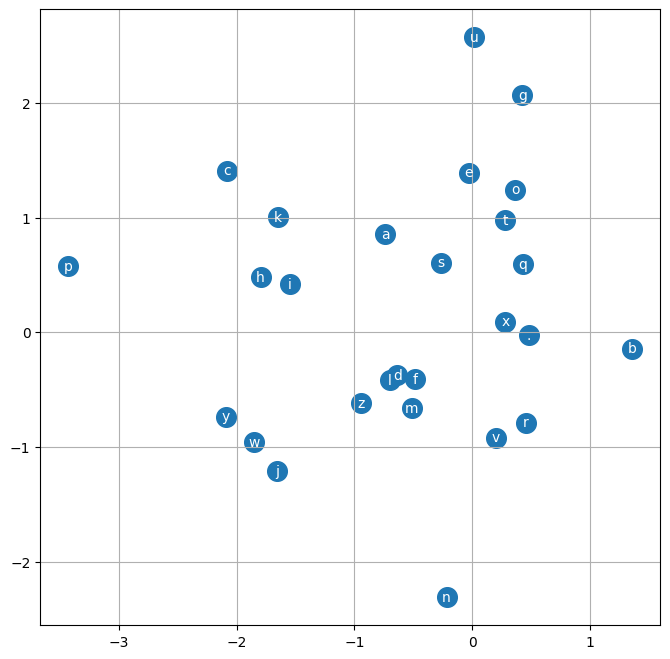

In [566]:
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
  plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color="white")
plt.grid('minor')